# KF7029 — Tabular Anomaly Detection: US DOT Pipeline Accidents
**Student:** Sibtain Mehdi Razvi Syed | **ID:** W25039720

## Overview
This notebook implements and evaluates anomaly detection models on the US DOT Oil Pipeline Accidents dataset. The goal is to detect corrosion-related pipeline defects under conditions of class imbalance, where corrosion incidents represent approximately 21% of all records.

**Models evaluated:**
- Classical baselines: Isolation Forest, One-Class SVM, PCA, Local Outlier Factor
- Deep learning: Feedforward Autoencoder

**Anomaly definition:** Corrosion incidents (PHMSA cause code: CORROSION) are treated as the anomalous class. All models are trained exclusively on normal (non-corrosion) data. Labels are used only for evaluation and threshold calibration.

## 1. Imports
Standard libraries for data manipulation, visualisation, machine learning, and deep learning. All classical models use scikit-learn. The Feedforward Autoencoder uses PyTorch.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.decomposition import PCA
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import (roc_auc_score, f1_score, precision_score,
                              recall_score, average_precision_score)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

print('All libraries imported successfully')

All libraries imported successfully


## 2. Load Data
Source: US Department of Transportation, Pipeline and Hazardous Materials Safety Administration (PHMSA). Available on Kaggle under CC0 Public Domain licence. Dataset contains 2,795 real pipeline accident records with 48 features covering incident cause, severity, location, and financial impact.

In [2]:
df = pd.read_csv(r'C:\Users\Administrator\Documents\kf7029-w25039720\datasets\usdot-pipeline-accidents\database.csv')

print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head(3)

Shape: (2795, 48)
Columns: ['Report Number', 'Supplemental Number', 'Accident Year', 'Accident Date/Time', 'Operator ID', 'Operator Name', 'Pipeline/Facility Name', 'Pipeline Location', 'Pipeline Type', 'Liquid Type', 'Liquid Subtype', 'Liquid Name', 'Accident City', 'Accident County', 'Accident State', 'Accident Latitude', 'Accident Longitude', 'Cause Category', 'Cause Subcategory', 'Unintentional Release (Barrels)', 'Intentional Release (Barrels)', 'Liquid Recovery (Barrels)', 'Net Loss (Barrels)', 'Liquid Ignition', 'Liquid Explosion', 'Pipeline Shutdown', 'Shutdown Date/Time', 'Restart Date/Time', 'Public Evacuations', 'Operator Employee Injuries', 'Operator Contractor Injuries', 'Emergency Responder Injuries', 'Other Injuries', 'Public Injuries', 'All Injuries', 'Operator Employee Fatalities', 'Operator Contractor Fatalities', 'Emergency Responder Fatalities', 'Other Fatalities', 'Public Fatalities', 'All Fatalities', 'Property Damage Costs', 'Lost Commodity Costs', 'Public/Privat

,Report Number,Supplemental Number,Accident Year,Accident Date/Time,Operator ID,Operator Name,Pipeline/Facility Name,Pipeline Location,Pipeline Type,Liquid Type,...,Other Fatalities,Public Fatalities,All Fatalities,Property Damage Costs,Lost Commodity Costs,Public/Private Property Damage Costs,Emergency Response Costs,Environmental Remediation Costs,Other Costs,All Costs
0,20100016,17305,2010,1/1/2010 7:15 AM,32109,ONEOK NGL PIPELINE LP,KINDER MORGAN JCT,ONSHORE,ABOVEGROUND,"HVL OR OTHER FLAMMABLE OR TOXIC FLUID, GAS",...,NaN,NaN,NaN,110.0,1517.0,0.0,0.0,0.0,0.0,1627
1,20100254,17331,2010,1/4/2010 8:30 AM,15786,PORTLAND PIPELINE CORP,24-INCH MAIN LINE,ONSHORE,ABOVEGROUND,CRUDE OIL,...,NaN,NaN,NaN,4000.0,8.0,0.0,0.0,0.0,0.0,4008
2,20100038,17747,2010,1/5/2010 10:30 AM,20160,"PETROLOGISTICS OLEFINS, LLC",NaN,ONSHORE,ABOVEGROUND,"HVL OR OTHER FLAMMABLE OR TOXIC FLUID, GAS",...,NaN,NaN,NaN,0.0,200.0,0.0,0.0,0.0,0.0,200


## 3. Exploratory Data Analysis
Understanding the dataset structure before any modelling decisions. Key things to examine: cause category distribution, missing value patterns, and severity indicators. This informs the labelling strategy and preprocessing decisions.

In [3]:
print('Cause Category counts:')
print(df['Cause Category'].value_counts())

print('\nNet Loss (Barrels) stats:')
print(df['Net Loss (Barrels)'].describe())

print('\nMissing values (top 10):')
print(df.isnull().sum().sort_values(ascending=False).head(10))

print('\nPipeline Type:')
print(df['Pipeline Type'].value_counts())

print('\nLiquid Type:')
print(df['Liquid Type'].value_counts())

Cause Category counts:
Cause Category
MATERIAL/WELD/EQUIP FAILURE    1435
CORROSION                       592
INCORRECT OPERATION             378
NATURAL FORCE DAMAGE            118
ALL OTHER CAUSES                118
EXCAVATION DAMAGE                97
OTHER OUTSIDE FORCE DAMAGE       57
Name: count, dtype: int64

Net Loss (Barrels) stats:
count     2795.000000
mean       132.194050
std       1185.019252
min          0.000000
25%          0.000000
50%          0.000000
75%          2.000000
max      30565.000000
Name: Net Loss (Barrels), dtype: float64

Missing values (top 10):
Public Fatalities                 2787
All Fatalities                    2787
Operator Employee Fatalities      2787
Other Fatalities                  2787
Emergency Responder Fatalities    2787
Operator Contractor Fatalities    2787
Operator Employee Injuries        2783
Emergency Responder Injuries      2783
Public Injuries                   2783
Operator Contractor Injuries      2783
dtype: int64

Pipeline T

## 4. Labelling Strategy
Corrosion is defined as the anomalous class based on domain knowledge and PHMSA operational criteria — not statistical frequency. Physical corrosion defects (INTERNAL and EXTERNAL subcategories) represent direct pipeline structural failure, which is the target of pipeline integrity management systems.

- **Normal:** 2,203 records (78.8%) — all non-corrosion incident causes
- **Anomalous:** 592 records (21.2%) — corrosion incidents only

This definition directly addresses the requirement that normality should not be inferred from frequency alone — MATERIAL/WELD/EQUIP FAILURE is the most frequent category but still represents a physical defect, not a normal operational state.

Normal (non-corrosion): 2203
Anomalous (corrosion): 592

Class ratio:
label
0    0.788
1    0.212
Name: proportion, dtype: float64

Corrosion subcategories:
Cause Subcategory
INTERNAL    362
EXTERNAL    230
Name: count, dtype: int64


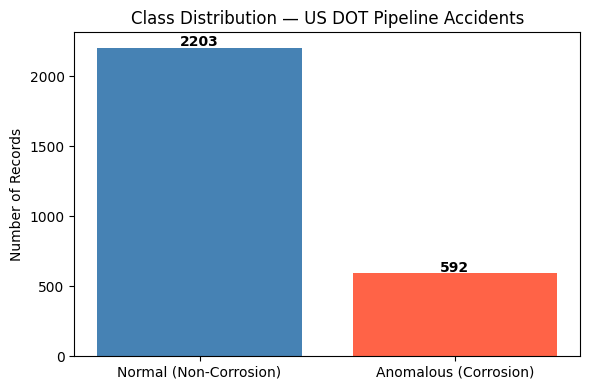

In [4]:
df['label'] = (df['Cause Category'] == 'CORROSION').astype(int)

print('Normal (non-corrosion):', (df['label'] == 0).sum())
print('Anomalous (corrosion):', (df['label'] == 1).sum())
print('\nClass ratio:')
print(df['label'].value_counts(normalize=True).round(3))

print('\nCorrosion subcategories:')
print(df[df['Cause Category'] == 'CORROSION']['Cause Subcategory'].value_counts())

# Plot class distribution
plt.figure(figsize=(6, 4))
counts = df['label'].value_counts()
plt.bar(['Normal (Non-Corrosion)', 'Anomalous (Corrosion)'],
        counts.values, color=['steelblue', 'tomato'])
plt.title('Class Distribution — US DOT Pipeline Accidents')
plt.ylabel('Number of Records')
for i, v in enumerate(counts.values):
    plt.text(i, v + 10, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(r'C:\Users\Administrator\Documents\kf7029-w25039720\results\figures\class_distribution.png', dpi=150)
plt.show()

## 5. Preprocessing
Three steps applied in sequence:
1. **Drop irrelevant columns** — identifiers, free text fields, timestamps with excessive missing values
2. **Drop label-leaking columns** — Cause Category and Cause Subcategory directly encode the label and must be removed to prevent trivial results
3. **Handle missing values** — mode imputation for categorical, median imputation for continuous cost columns
4. **Encode categorical features** — binary columns mapped to 0/1, remaining categoricals one-hot encoded

Result: 72 numerical features, zero missing values.

In [5]:
# Drop irrelevant and label-leaking columns
cols_to_drop = [
    'Report Number', 'Supplemental Number', 'Accident Date/Time',
    'Operator ID', 'Operator Name', 'Pipeline/Facility Name',
    'Accident City', 'Accident County', 'Liquid Subtype', 'Liquid Name',
    'Shutdown Date/Time', 'Restart Date/Time',
    'Operator Employee Injuries', 'Operator Contractor Injuries',
    'Emergency Responder Injuries', 'Other Injuries', 'Public Injuries',
    'All Injuries', 'Operator Employee Fatalities',
    'Operator Contractor Fatalities', 'Emergency Responder Fatalities',
    'Other Fatalities', 'Public Fatalities', 'All Fatalities',
    'Intentional Release (Barrels)', 'Public Evacuations', 'Pipeline Shutdown',
    'Cause Category', 'Cause Subcategory'  # label leakage — must be dropped
]
df_clean = df.drop(columns=cols_to_drop)

# Impute missing values
df_clean['Pipeline Type'] = df_clean['Pipeline Type'].fillna(df_clean['Pipeline Type'].mode()[0])
df_clean['Accident State'] = df_clean['Accident State'].fillna(df_clean['Accident State'].mode()[0])

cost_cols = ['Property Damage Costs', 'Lost Commodity Costs',
             'Public/Private Property Damage Costs', 'Emergency Response Costs',
             'Environmental Remediation Costs', 'Other Costs']
for col in cost_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Encode binary columns
df_clean['Liquid Ignition'] = (df_clean['Liquid Ignition'] == 'YES').astype(int)
df_clean['Liquid Explosion'] = (df_clean['Liquid Explosion'] == 'YES').astype(int)

# One-hot encode categorical columns
df_clean = pd.get_dummies(df_clean, columns=[
    'Pipeline Location', 'Pipeline Type', 'Liquid Type', 'Accident State'])

print('Original shape:', df.shape)
print('Clean shape:', df_clean.shape)
print('Missing values remaining:', df_clean.isnull().sum().sum())
print('Features:', df_clean.shape[1] - 1)

Original shape: (2795, 49)
Clean shape: (2795, 73)
Missing values remaining: 0
Features: 72


## 6. Train / Validation / Test Split
Stratified split to preserve class proportions across all sets:
- **Train (normal only):** 1,541 records — models never see anomalies during training
- **Validation:** 280 records — used for threshold calibration only, not for training
- **Test:** 559 records (441 normal, 118 anomalous) — held out for final evaluation

StandardScaler is fitted on normal training data only and then applied to validation and test sets. This strictly prevents data leakage.

In [6]:
X = df_clean.drop(columns=['label']).values.astype(float)
y = df_clean['label'].values

# Stratified splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.125, random_state=42, stratify=y_train)

# Keep only normal records for training
X_train_normal = X_train[y_train == 0]

# Scale — fit on normal training data only
scaler = StandardScaler()
scaler.fit(X_train_normal)
X_train_normal_scaled = scaler.transform(X_train_normal)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print('Train normal:', X_train_normal_scaled.shape)
print('Validation:', X_val_scaled.shape)
print('Test:', X_test_scaled.shape)
print(f'Test — Normal: {(y_test==0).sum()} | Anomalous: {(y_test==1).sum()}')

Train normal: (1541, 72)
Validation: (280, 72)
Test: (559, 72)
Test — Normal: 441 | Anomalous: 118


## 7. Evaluation Function
Computes five metrics for every model:
- **ROC-AUC:** overall discrimination ability regardless of threshold
- **PR-AUC:** more appropriate than ROC-AUC under class imbalance — focuses on the minority anomalous class
- **F1-score, Precision, Recall:** threshold-dependent performance metrics

Threshold is set at the 79th percentile of anomaly scores, matching the known anomaly ratio of approximately 21%.

In [7]:
results = {}

def evaluate_model(name, scores, preds, y_true):
    """Compute and store evaluation metrics for a given model."""
    results[name] = {
        'ROC-AUC':   round(roc_auc_score(y_true, scores), 4),
        'PR-AUC':    round(average_precision_score(y_true, scores), 4),
        'F1':        round(f1_score(y_true, preds), 4),
        'Precision': round(precision_score(y_true, preds), 4),
        'Recall':    round(recall_score(y_true, preds), 4)
    }
    print(f'\n=== {name} ===')
    for metric, value in results[name].items():
        print(f'  {metric}: {value}')

print('Evaluation function ready')

Evaluation function ready


## 8. Classical Baseline — Isolation Forest
Isolation Forest detects anomalies by randomly partitioning the feature space. Anomalies require fewer partitions to isolate than normal points. The contamination parameter is set to 0.21 to reflect the known anomaly ratio. Trained on normal data only.

**Reference:** Liu, Ting & Zhou (2008). Isolation Forest. IEEE ICDM.

In [8]:
iso = IsolationForest(n_estimators=100, contamination=0.21, random_state=42)
iso.fit(X_train_normal_scaled)

iso_scores = -iso.score_samples(X_test_scaled)  # higher = more anomalous
iso_preds = (iso_scores > np.percentile(iso_scores, 79)).astype(int)

evaluate_model('Isolation Forest', iso_scores, iso_preds, y_test)


=== Isolation Forest ===
  ROC-AUC: 0.5639
  PR-AUC: 0.2536
  F1: 0.3051
  Precision: 0.3051
  Recall: 0.3051


## 9. Classical Baseline — One-Class SVM
One-Class SVM learns a hypersphere boundary around normal data in a kernel-projected feature space. Points outside the boundary are flagged as anomalous. RBF kernel used with nu=0.21 matching the known anomaly ratio.

**Reference:** Schölkopf et al. (2001). Estimating the Support of a High-Dimensional Distribution. Neural Computation.

In [9]:
ocsvm = OneClassSVM(kernel='rbf', gamma='scale', nu=0.21)
ocsvm.fit(X_train_normal_scaled)

ocsvm_scores = -ocsvm.score_samples(X_test_scaled)
ocsvm_preds = (ocsvm_scores > np.percentile(ocsvm_scores, 79)).astype(int)

evaluate_model('One-Class SVM', ocsvm_scores, ocsvm_preds, y_test)


=== One-Class SVM ===
  ROC-AUC: 0.451
  PR-AUC: 0.1971
  F1: 0.1695
  Precision: 0.1695
  Recall: 0.1695


## 10. Classical Baseline — PCA Reconstruction Error
PCA projects data into a lower-dimensional subspace capturing 95% of the variance in normal training data. Anomaly score is the mean squared reconstruction error — anomalies are expected to reconstruct poorly because the principal components do not capture their variance patterns.

In [10]:
pca = PCA(n_components=0.95, random_state=42)
pca.fit(X_train_normal_scaled)

X_test_recon = pca.inverse_transform(pca.transform(X_test_scaled))
pca_scores = np.mean(np.power(X_test_scaled - X_test_recon, 2), axis=1)
pca_preds = (pca_scores > np.percentile(pca_scores, 79)).astype(int)

print(f'PCA components retained: {pca.n_components_}')
evaluate_model('PCA', pca_scores, pca_preds, y_test)

PCA components retained: 53

=== PCA ===
  ROC-AUC: 0.4742
  PR-AUC: 0.1973
  F1: 0.1356
  Precision: 0.1356
  Recall: 0.1356


## 11. Classical Baseline — Local Outlier Factor
LOF computes anomaly scores based on local density deviation. Points located in significantly lower-density regions than their neighbours are flagged as anomalous. n_neighbors=20 following standard practice.

**Reference:** Breunig et al. (2000). LOF: Identifying Density-Based Local Outliers. ACM SIGMOD.

In [11]:
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.21, novelty=True)
lof.fit(X_train_normal_scaled)

lof_scores = -lof.score_samples(X_test_scaled)
lof_preds = (lof_scores > np.percentile(lof_scores, 79)).astype(int)

evaluate_model('LOF', lof_scores, lof_preds, y_test)


=== LOF ===
  ROC-AUC: 0.5127
  PR-AUC: 0.2231
  F1: 0.2034
  Precision: 0.2034
  Recall: 0.2034


## 12. Deep Learning — Feedforward Autoencoder (Architecture)
The Autoencoder learns to compress and reconstruct normal pipeline incident patterns through a bottleneck layer. Architecture: 72 → 32 → 16 → 8 (bottleneck) → 16 → 32 → 72.

Trained exclusively on normal data using MSE reconstruction loss. At inference, anomalies produce higher reconstruction error because the model has never encountered their patterns during training. Anomaly score = mean squared reconstruction error per sample.

In [12]:
input_dim = X_train_normal_scaled.shape[1]

class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32), nn.ReLU(),
            nn.Linear(32, 16),        nn.ReLU(),
            nn.Linear(16, 8)
        )
        self.decoder = nn.Sequential(
            nn.Linear(8, 16),         nn.ReLU(),
            nn.Linear(16, 32),        nn.ReLU(),
            nn.Linear(32, input_dim)
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

model = Autoencoder(input_dim)
print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}')

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=72, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=8, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=8, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=72, bias=True)
  )
)

Total parameters: 6,064


## 13. Deep Learning — Feedforward Autoencoder (Training)
Adam optimiser with learning rate 0.001. Batch size 32. Trained for 100 epochs on normal data only. MSE loss measures how well the model reconstructs normal patterns.

Epoch 20/100 — Loss: 0.552446
Epoch 40/100 — Loss: 0.473896
Epoch 60/100 — Loss: 0.428102
Epoch 80/100 — Loss: 0.412293
Epoch 100/100 — Loss: 0.390927


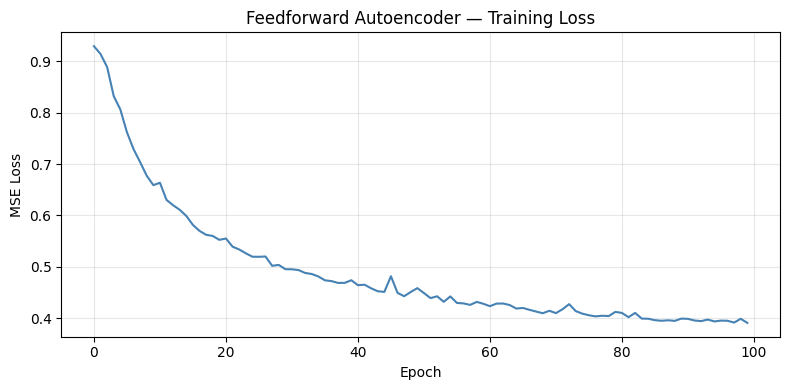

In [13]:
X_train_tensor = torch.FloatTensor(X_train_normal_scaled)
X_test_tensor  = torch.FloatTensor(X_test_scaled)

train_loader = DataLoader(
    TensorDataset(X_train_tensor, X_train_tensor),
    batch_size=32, shuffle=True)

optimizer  = torch.optim.Adam(model.parameters(), lr=0.001)
criterion  = nn.MSELoss()
train_losses = []

for epoch in range(100):
    model.train()
    total_loss = 0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(batch_x), batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    if (epoch + 1) % 20 == 0:
        print(f'Epoch {epoch+1}/100 — Loss: {avg_loss:.6f}')

# Plot training loss
plt.figure(figsize=(8, 4))
plt.plot(train_losses, color='steelblue')
plt.title('Feedforward Autoencoder — Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(r'C:\Users\Administrator\Documents\kf7029-w25039720\results\figures\ae_training_loss.png', dpi=150)
plt.show()

## 14. Deep Learning — Feedforward Autoencoder (Evaluation)
Reconstruction error computed on the test set. Threshold set at the 79th percentile of anomaly scores to match the known anomaly ratio.

In [14]:
model.eval()
with torch.no_grad():
    ae_scores = torch.mean(
        torch.pow(X_test_tensor - model(X_test_tensor), 2), dim=1).numpy()

ae_preds = (ae_scores > np.percentile(ae_scores, 79)).astype(int)
evaluate_model('Feedforward Autoencoder', ae_scores, ae_preds, y_test)


=== Feedforward Autoencoder ===
  ROC-AUC: 0.5135
  PR-AUC: 0.2121
  F1: 0.1525
  Precision: 0.1525
  Recall: 0.1525


## 15. Results Summary
Complete comparison of all five models across all evaluation metrics.

=== COMPLETE RESULTS ===
                         ROC-AUC  PR-AUC      F1  Precision  Recall
Isolation Forest          0.5639  0.2536  0.3051     0.3051  0.3051
One-Class SVM             0.4510  0.1971  0.1695     0.1695  0.1695
PCA                       0.4742  0.1973  0.1356     0.1356  0.1356
LOF                       0.5127  0.2231  0.2034     0.2034  0.2034
Feedforward Autoencoder   0.5135  0.2121  0.1525     0.1525  0.1525


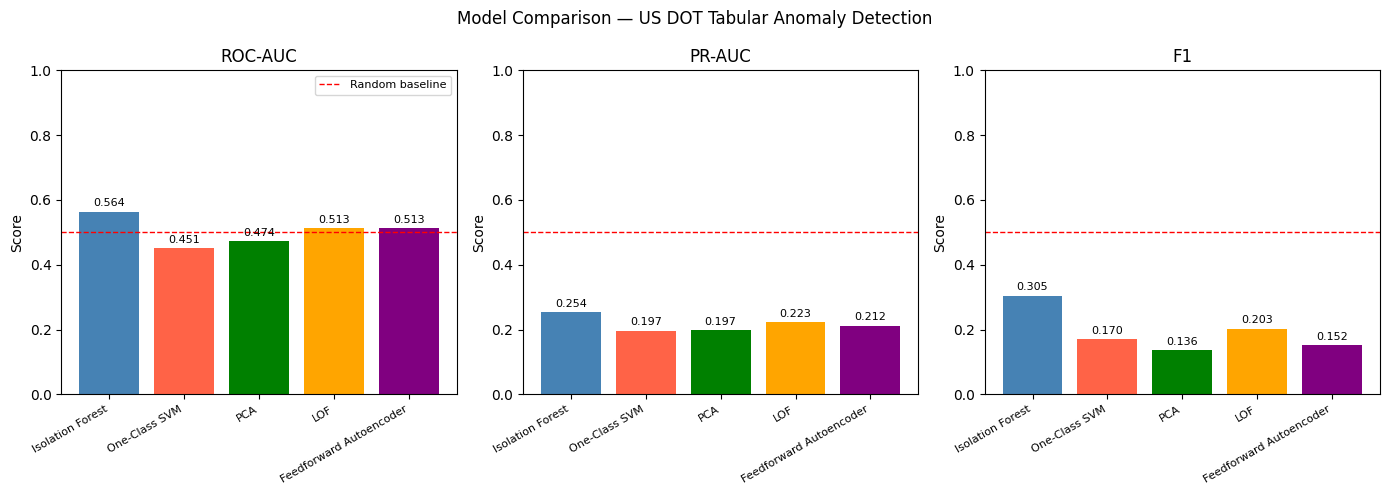

In [15]:
results_df = pd.DataFrame(results).T
print('=== COMPLETE RESULTS ===')
print(results_df.to_string())

# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

metrics = ['ROC-AUC', 'PR-AUC', 'F1']
colors  = ['steelblue', 'tomato', 'green', 'orange', 'purple']

for ax, metric in zip(axes, metrics):
    bars = ax.bar(results_df.index, results_df[metric], color=colors)
    ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1, label='Random baseline')
    ax.set_title(metric)
    ax.set_ylim(0, 1)
    ax.set_xticklabels(results_df.index, rotation=30, ha='right', fontsize=8)
    ax.set_ylabel('Score')
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

axes[0].legend(fontsize=8)
plt.suptitle('Model Comparison — US DOT Tabular Anomaly Detection', fontsize=12)
plt.tight_layout()
plt.savefig(r'C:\Users\Administrator\Documents\kf7029-w25039720\results\figures\model_comparison_tabular.png', dpi=150)
plt.show()

## Results Interpretation
All five models show weak performance on this dataset, with ROC-AUC scores close to or below the 0.5 random baseline. Isolation Forest performs best among all methods (ROC-AUC: 0.5639). The Feedforward Autoencoder does not outperform classical baselines in this single-run evaluation.

These results reflect the genuine difficulty of this detection task. The tabular features available in the US DOT dataset — operational metadata, cost figures, and location data — do not strongly discriminate corrosion from non-corrosion incidents. Corrosion incidents do not exhibit consistently different operational signatures from other failure types in this dataset.

This finding is itself an important contribution: it demonstrates that tabular operational metadata alone is insufficient for reliable corrosion anomaly detection, which motivates the use of visual inspection data (K-Pipelines image modality) where corrosion produces distinctive visual patterns.

Statistical significance across 10 independent runs will be assessed in the next stage using the Wilcoxon signed-rank test with Bonferroni correction.

## 16. Save Results and Models

In [16]:
# Save results table
results_df.to_csv(
    r'C:\Users\Administrator\Documents\kf7029-w25039720\results\tabular_results.csv')

# Save results dictionary
with open(r'C:\Users\Administrator\Documents\kf7029-w25039720\results\all_results.pkl', 'wb') as f:
    pickle.dump(results, f)

# Save preprocessed splits
np.save(r'C:\Users\Administrator\Documents\kf7029-w25039720\datasets\usdot-pipeline-accidents\X_train_normal.npy', X_train_normal_scaled)
np.save(r'C:\Users\Administrator\Documents\kf7029-w25039720\datasets\usdot-pipeline-accidents\X_val.npy', X_val_scaled)
np.save(r'C:\Users\Administrator\Documents\kf7029-w25039720\datasets\usdot-pipeline-accidents\X_test.npy', X_test_scaled)
np.save(r'C:\Users\Administrator\Documents\kf7029-w25039720\datasets\usdot-pipeline-accidents\y_val.npy', y_val)
np.save(r'C:\Users\Administrator\Documents\kf7029-w25039720\datasets\usdot-pipeline-accidents\y_test.npy', y_test)

# Save trained model
torch.save(model.state_dict(),
    r'C:\Users\Administrator\Documents\kf7029-w25039720\models\saved_models\feedforward_autoencoder.pth')

print('All results, data splits, and models saved successfully.')
print('\nSaved files:')
print('  results/tabular_results.csv')
print('  results/all_results.pkl')
print('  results/figures/class_distribution.png')
print('  results/figures/ae_training_loss.png')
print('  results/figures/model_comparison_tabular.png')
print('  models/saved_models/feedforward_autoencoder.pth')

All results, data splits, and models saved successfully.

Saved files:
  results/tabular_results.csv
  results/all_results.pkl
  results/figures/class_distribution.png
  results/figures/ae_training_loss.png
  results/figures/model_comparison_tabular.png
  models/saved_models/feedforward_autoencoder.pth
